# PSY 39200 Introduction to Computational Psychology and AI

## Week 13 Transformer and Natural Language Processing

## There is 1 question and 0 coding exercises in this tutorial

## Zhixian Han <br> Department of Psychological Sciences <br> Purdue University

### This tutorial is adapted from Neuromatch Academy Tutorials (CC-BY licensed) https://neuromatch.io/open-education-resources/






In [1]:
# @title Install dependencies
# @markdown There may be *errors* and/or *warnings* reported during the installation. However, they are to be ignored.
!pip install tensorboard --quiet
!pip install -U transformers --quiet
!pip install -U datasets --quiet
!pip install fasttext --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 12.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 6.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# @title Set environment variables

import os
os.environ['TA_CACHE_DIR'] = 'data/'
os.environ['NLTK_DATA'] = 'nltk_data/'

In [3]:
# Imports
import os
import sys
import math
import nltk
import torch
import random
import string
import datasets
import fasttext
import statistics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pprint import pprint
from tqdm.notebook import tqdm
from abc import ABC, abstractmethod

from nltk.corpus import brown
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, BertTokenizer, BertModel, BertForMaskedLM

%load_ext tensorboard

In [4]:
# @title Figure settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/content-creation/main/nma.mplstyle")

In [5]:
# @title Download NLTK data (`punkt`, `averaged_perceptron_tagger`, `brown`, `webtext`)

"""
NLTK Download:

import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('brown')
nltk.download('webtext')
"""

import os, requests, zipfile

os.environ['NLTK_DATA'] = 'nltk_data/'

fname = 'nltk_data.zip'
url = 'https://osf.io/download/zqw5s/'

r = requests.get(url, allow_redirects=True)

with open(fname, 'wb') as fd:
  fd.write(r.content)

with zipfile.ZipFile(fname, 'r') as zip_ref:
  zip_ref.extractall('.')

In [6]:
# @title Helper functions
global category
global brown_wordlist
global w2vmodel
category = ['editorial', 'fiction', 'government', 'mystery', 'news',
                   'religion', 'reviews', 'romance', 'science_fiction']
brown_wordlist = list(brown.words(categories=category))

def create_word2vec_model(category = 'news', size = 50, sg = 1, min_count = 10):
    sentences = brown.sents(categories=category)
    with open("brown_sentences.txt", "w") as f:
        for sentence in sentences:
            f.write(" ".join(sentence) + "\n")
        model = fasttext.train_unsupervised('brown_sentences.txt',
                                            model='skipgram',
                                            dim=size,
                                            minCount=min_count)
    return model

w2vmodel = create_word2vec_model(category)

def model_dictionary(model):
  print(w2vmodel.words)
  return w2vmodel.words

def get_embedding(word, model):
  if word in model:
    return model[word]
  else:
    print(f' |{word}| not in model dictionary. Try another word')

def check_word_in_corpus(word, model):
  if word in model:
    print('Word present!')
    return model[word]
  else:
    print('Word NOT present!')
    return None

def get_embeddings(words, model):
  embed_list = [get_embedding(word, model) for word in words]
  return np.array(embed_list)

def similar_by_word(word, model):
  return model.get_nearest_neighbors(word)

def similar_by_vector(vector, model):
  vecs = [w2vmodel[w] for w in w2vmodel.words]
  x = cosine_similarity(vecs, [vector])
  top = np.argsort(x, axis=0)[::-1].flatten()
  return [w2vmodel.words[w] for w in top[:10]]

def softmax(x):
    f_x = np.exp(x) / np.sum(np.exp(x))
    return f_x

In [7]:
# @title Set random seed

# @markdown Executing `set_seed(seed=seed)` you are setting the seed

# for DL its critical to set the random seed so that students can have a
# baseline to compare their results to expected results.
# Read more here: https://pytorch.org/docs/stable/notes/randomness.html

# Call `set_seed` function in the exercises to ensure reproducibility.
import random
import torch

def set_seed(seed=None, seed_torch=True):
  """
  Handles variability by controlling sources of randomness
  through set seed values

  Args:
    seed: Integer
      Set the seed value to given integer.
      If no seed, set seed value to random integer in the range 2^32
    seed_torch: Bool
      Seeds the random number generator for all devices to
      offer some guarantees on reproducibility

  Returns:
    Nothing
  """
  if seed is None:
    seed = np.random.choice(2 ** 32)
  random.seed(seed)
  np.random.seed(seed)
  if seed_torch:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

  print(f'Random seed {seed} has been set.')


# In case that `DataLoader` is used
def seed_worker(worker_id):
  """
  DataLoader will reseed workers following randomness in
  multi-process data loading algorithm.

  Args:
    worker_id: integer
      ID of subprocess to seed. 0 means that
      the data will be loaded in the main process
      Refer: https://pytorch.org/docs/stable/data.html#data-loading-randomness for more details

  Returns:
    Nothing
  """
  worker_seed = torch.initial_seed() % 2**32
  np.random.seed(worker_seed)
  random.seed(worker_seed)

In [8]:
# @title Set device (GPU or CPU). Execute `set_device()`
# especially if torch modules used.

# inform the user if the notebook uses GPU or CPU.

def set_device():
  """
  Set the device. CUDA if available, CPU otherwise

  Args:
    None

  Returns:
    Nothing
  """
  device = "cuda" if torch.cuda.is_available() else "cpu"
  if device != "cuda":
    print("WARNING: For this notebook to perform best, "
        "if possible, in the menu under `Runtime` -> "
        "`Change runtime type.`  select `GPU` ")
  else:
    print("GPU is enabled in this notebook.")

  return device

In [9]:
SEED = 2025
set_seed(seed=SEED)
DEVICE = set_device()

Random seed 2025 has been set.
GPU is enabled in this notebook.


# Natural Language Processing

## Time Series and Natural Language Processing (NLP)

## Embeddings

[Word2vec](https://rare-technologies.com/word2vec-tutorial/) is a group of related models that produce word embeddings. These models are shallow, two-layer neural networks trained to reconstruct linguistic contexts of words. Word2vec takes a large corpus of text as input and produces a vector space, with each unique word in the corpus being assigned a corresponding vector in the space.

### Creating Word Embeddings

We will create embeddings for a subset of categories in [Brown corpus](https://www1.essex.ac.uk/linguistics/external/clmt/w3c/corpus_ling/content/corpora/list/private/brown/brown.html). To achieve this task we will use [gensim](https://radimrehurek.com/gensim/) library to create word2vec embeddings. Gensim’s word2vec expects a sequence of sentences as its input. Each sentence is a list of words.

Calling Word2Vec(sentences, `iter=1`) will run two passes over the sentences iterator (generally, `iter+1` passes). The first pass collects words and their frequencies to build an internal dictionary tree structure. The second and subsequent passes train the neural model.
Word2vec accepts several parameters that affect both training speed and quality.

One of them is for pruning the internal dictionary. Words that appear only once or twice in a billion-word corpus are probably uninteresting typos and garbage. In addition, there are not enough data to make any meaningful training on those words, so it’s best to ignore them:

```python
model = Word2Vec(sentences, min_count=10)  # default value is 5
```

A reasonable value for `min_count` is bewteen 0-100, depending on the size of your dataset.

Another parameter is the `size` of the NN layers, which correspond to the “degrees” of freedom the training algorithm has:

```python
model = Word2Vec(sentences, size=200)  # default value is 100
```

Bigger `size` values require more training data but can lead to better (more accurate) models. Reasonable values are in the tens to hundreds.

The last of the major parameters (full list [here](https://radimrehurek.com/gensim/models/word2vec.html#gensim.models.word2vec.Word2Vec)) is for training parallelization, to speed up training:

```python
model = Word2Vec(sentences, workers=4)  # default = 1 worker = no parallelization
```

In [10]:
# Categories used for the Brown corpus
category = ['editorial', 'fiction', 'government', 'mystery', 'news', 'religion',
            'reviews', 'romance', 'science_fiction']

In [11]:
# @markdown Word2Vec model

!pip install gensim
from gensim.models import Word2Vec as Word2Vec_gensim
from nltk.corpus import brown

def create_word2vec_model(category='news', size=50, sg=1, min_count=5):
  sentences = brown.sents(categories=category)
  model = Word2Vec_gensim(sentences, vector_size=size,
                   sg=sg, min_count=min_count)
  return model


def model_dictionary(model):
  print(w2vmodel.wv)
  words = list(w2vmodel.wv)
  return words


def get_embedding(word, model):
  if word in w2vmodel.wv:
    return model.wv[word]
  else:
    return None

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.6 MB/s eta 0:00:00


The cell will take 30-45 seconds to run.

In [12]:

# Create a word2vec model based on categories from Brown corpus
w2vmodel = create_word2vec_model(category)

You can get the embedding vector for a word in the dictionary.

In [13]:
# get word list from Brown corpus
brown_wordlist = list(brown.words(categories=category))
# generate a random word
random_word = random.sample(brown_wordlist, 1)[0]
# get embedding of the random word
random_word_embedding = get_embedding(random_word, w2vmodel)
print(f'Embedding of "{random_word}" is {random_word_embedding}')

Embedding of "from" is [-0.22039224 -0.21011846 -0.26181313  0.28839958 -0.38621742 -0.328667
  0.26043677  0.12908626 -0.13031563  0.3435034  -0.3086806   0.00411992
  0.29876116  0.03591694 -0.15654936  0.7375335   0.62841046  0.09759281
  0.33646184 -0.42008367 -0.27335215 -0.26399544  0.4162681   0.07061134
  0.3059375   0.08796314  0.00995918  0.08667685 -0.69097114 -0.34812963
 -0.59470195 -0.08907363  0.11462434  0.19510192 -0.37269762 -0.14122817
 -0.0053936  -0.24443316  0.2629332   0.355671   -0.01673692  0.04230081
 -0.13158934 -0.19401242  0.47341803  0.40421525  0.39757088 -0.78805083
  0.47924656  0.65358955]


### Visualizing Word Embeddings

We can now obtain the word embeddings for any word in the dictionary using word2vec. Let's visualize these embeddings to get an intuition of what these embeddings mean. The word embeddings obtained from the word2vec model are in high dimensional space, and we will use tSNE to pick the two features that capture the most variance in the embeddings to represent them in a 2D space.

For each word in `keys`, we pick the top 10 similar words (using cosine similarity) and plot them.

Before you run the code, spend some time to think:

- What should be the arrangement of similar words?
- What should be the arrangement of the critical clusters with respect to each other?

In [14]:
keys = ['voters', 'magic', 'love', 'God', 'evidence', 'administration', 'governments']

In [15]:
# @markdown ### Cluster embeddings related functions

# @markdown **Note:** We import [sklearn.manifold.TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)
from sklearn.manifold import TSNE
import matplotlib.cm as cm

def get_cluster_embeddings(keys):
  embedding_clusters = []
  word_clusters = []

  # find closest words and add them to cluster
  for word in keys:
    embeddings = []
    words = []
    if not word in w2vmodel.wv:
      print(f'The word {word} is not in the dictionary')
      continue

    for similar_word, _ in w2vmodel.wv.most_similar(word, topn=10):
      words.append(similar_word)
      embeddings.append(w2vmodel.wv[similar_word])
    embeddings.append(get_embedding(word, w2vmodel))
    words.append(word)
    embedding_clusters.append(embeddings)
    word_clusters.append(words)

  # get embeddings for the words in clusers
  embedding_clusters = np.array(embedding_clusters)
  n, m, k = embedding_clusters.shape
  tsne_model_en_2d = TSNE(perplexity=10, n_components=2, init='pca', n_iter=3500, random_state=32)
  embeddings_en_2d = np.array(tsne_model_en_2d.fit_transform(embedding_clusters.reshape(n * m, k))).reshape(n, m, 2)
  return embeddings_en_2d, word_clusters


def tsne_plot_similar_words(title, labels, embedding_clusters,
                            word_clusters, opacity, filename=None):
  plt.figure(figsize=(16, 9))
  colors = cm.rainbow(np.linspace(0, 1, len(labels)))
  for label, embeddings, words, color in zip(labels, embedding_clusters, word_clusters, colors):
    x = embeddings[:, 0]
    y = embeddings[:, 1]
    plt.scatter(x, y, color=color, alpha=opacity, label=label)
    # Plot the cluster centroids
    plt.plot(np.mean(x), np.mean(y), 'x', color=color, markersize=16)
    for i, word in enumerate(words):
      size = 10 if i < 10 else 14
      plt.annotate(word, alpha=0.5, xy=(x[i], y[i]), xytext=(5, 2),
                    textcoords='offset points',
                    ha='right', va='bottom', size=size)
  plt.legend()
  plt.title(title)
  plt.grid(True)
  if filename:
    plt.savefig(filename, format='png', dpi=150, bbox_inches='tight')
  plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


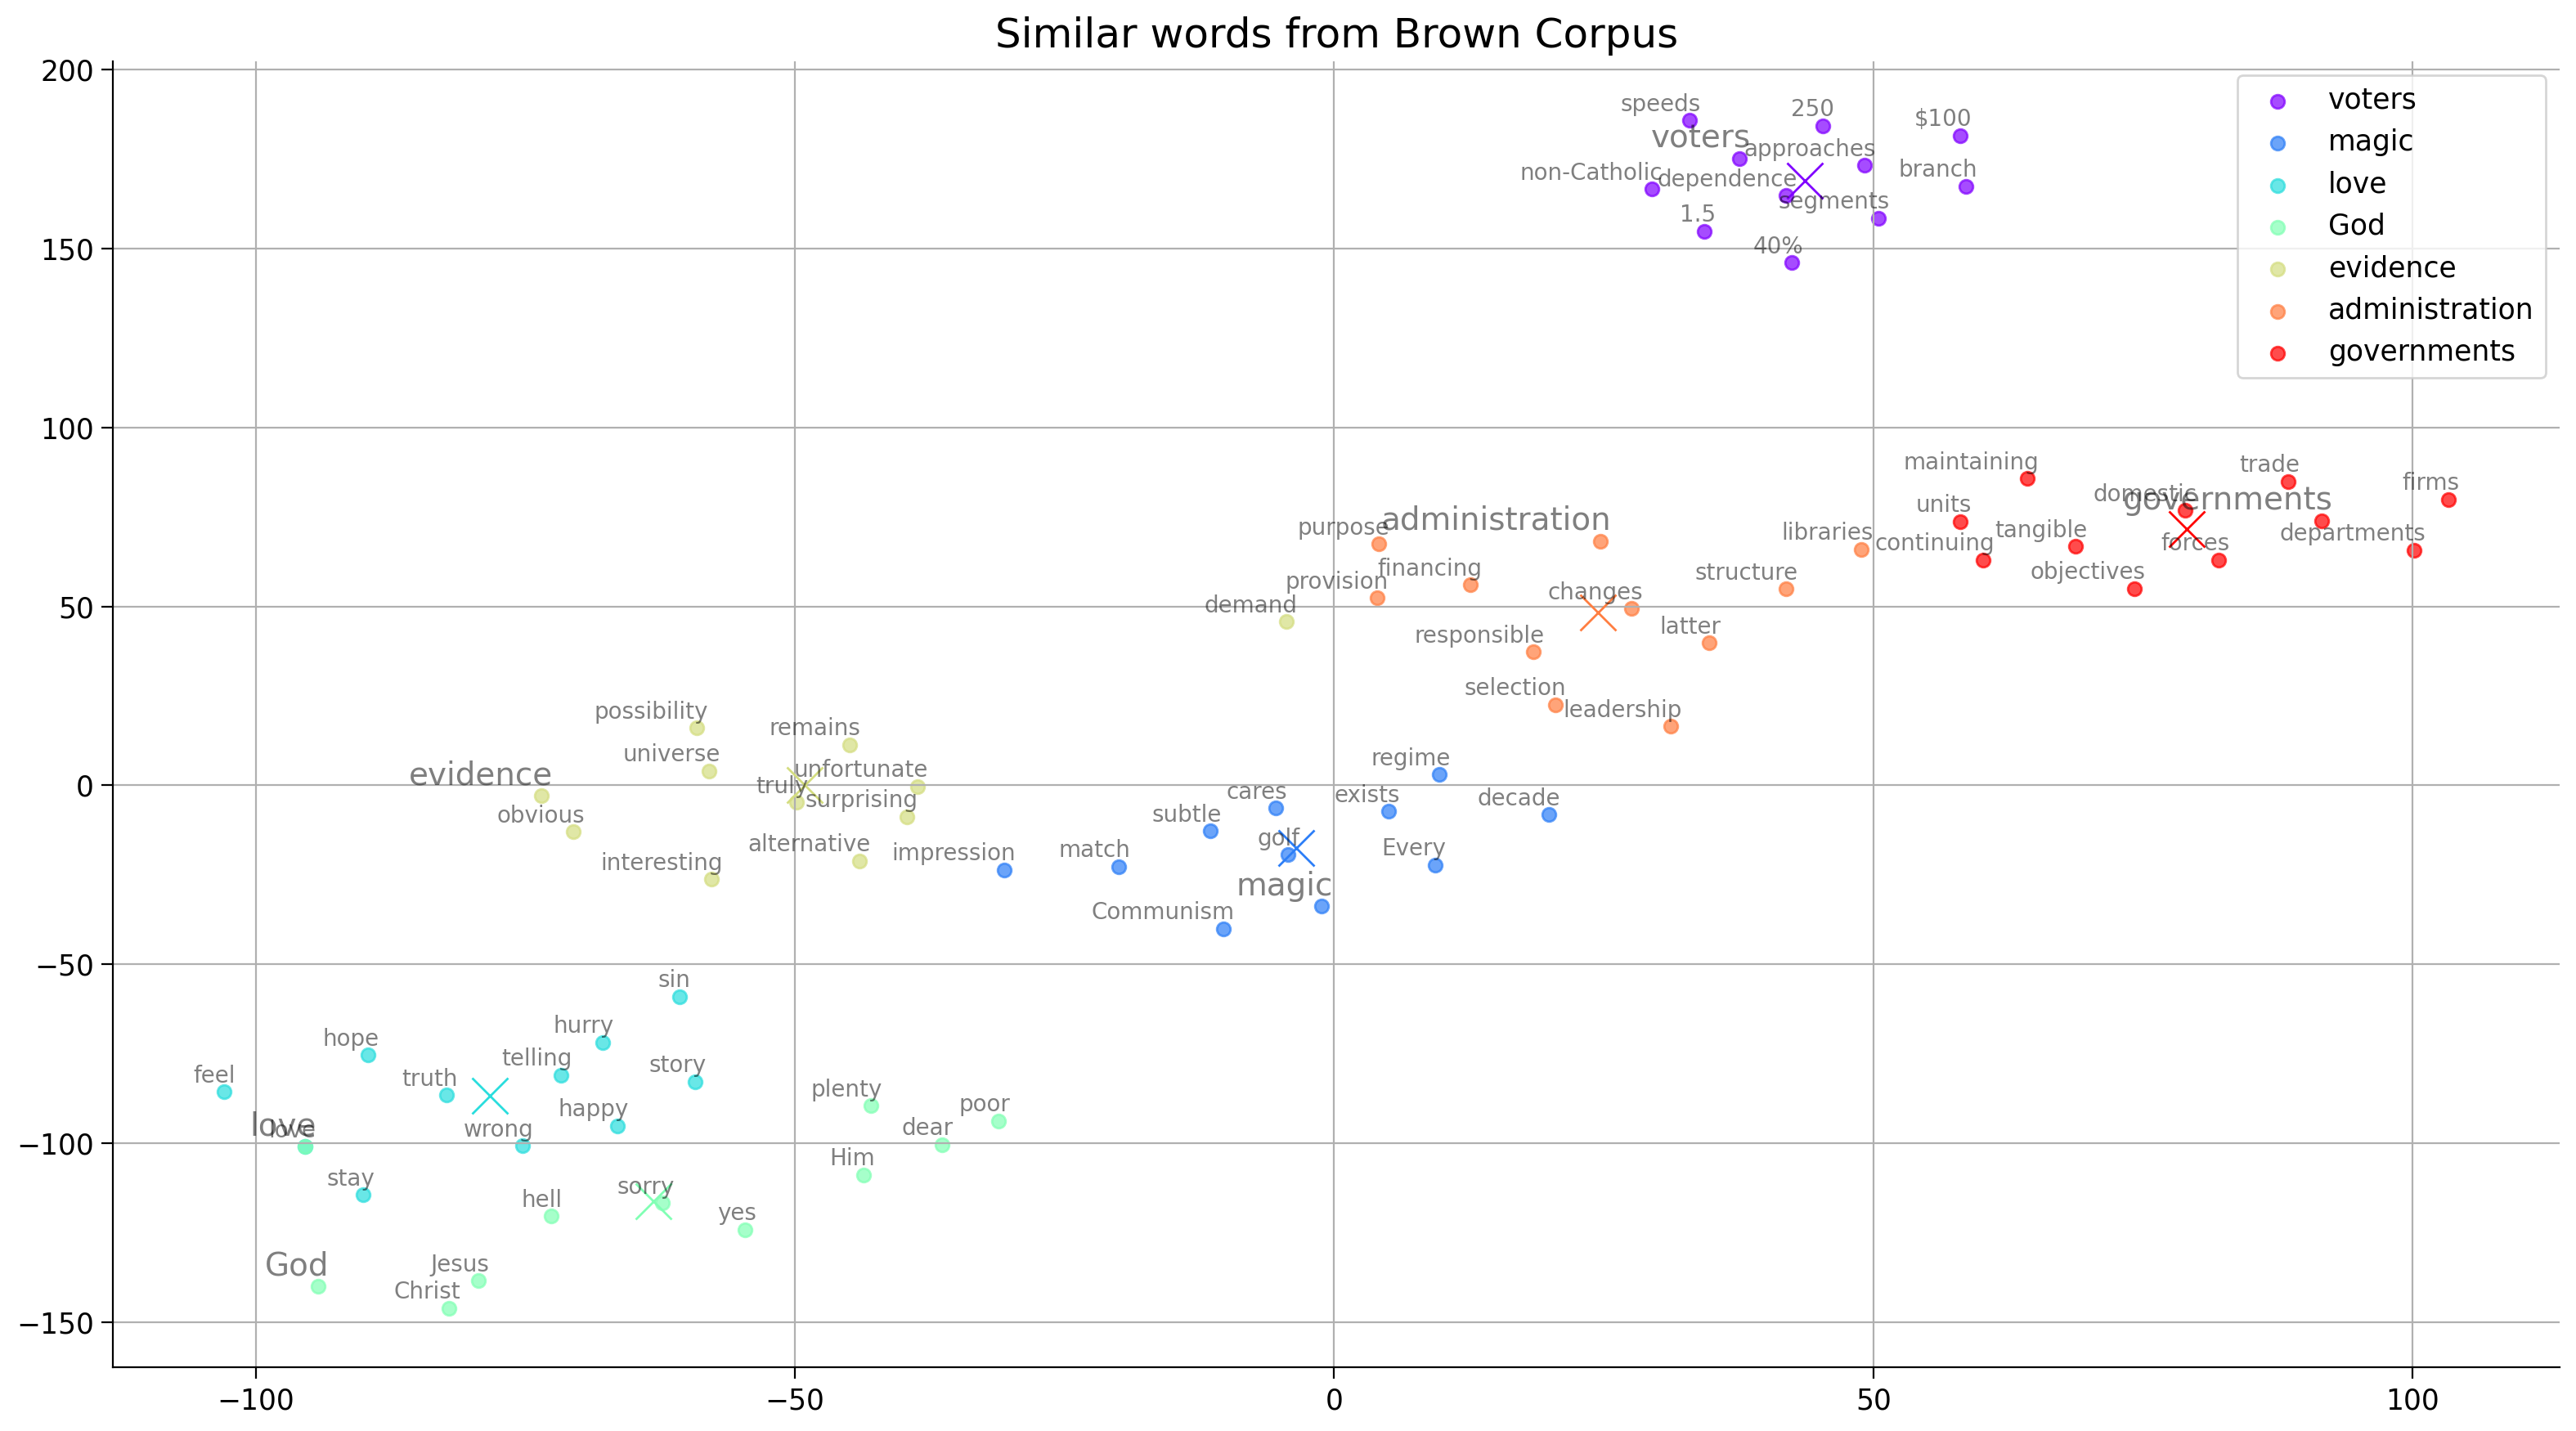

In [16]:
# Get closest words to the keys and get clusters of these words
embeddings_en_2d, word_clusters = get_cluster_embeddings(keys)
# tSNE plot of similar words to keys
tsne_plot_similar_words(title='Similar words from Brown Corpus',
                        labels=keys,
                        embedding_clusters=embeddings_en_2d,
                        word_clusters=word_clusters,
                        opacity=0.7,
                        filename='similar_words.png')

# Question 1

1. What does having higher similarity between two word embeddings mean?
2. Why are cluster centroids (represented with X in the plot) close to some keys (represented with larger fonts) but farther from others?

1. They are closer in semantic meaning and they tend to appear in similar linguistic contexts.
2. The centroid is the average location of the key word and its nearby similar words in the plot. It will be close to the key if the similar words are distributed roughly around it, but farther away if the neighbors are spread unevenly or mostly lie on one side of the key.

## Embedding exploration

Words or subword units such as morphemes are the basic units we use to express meaning in language. The technique of mapping words to vectors of real numbers is known as word embedding.

In this section, we will use pretrained `fastText` embeddings, a context-oblivious embedding similar to `word2vec`.

### Embedding Manipulation

Let's use the [FastText](https://fasttext.cc/) library to manipulate the embeddings. First, find the embedding for the word "King"

In [17]:
# @markdown ### Download FastText English Embeddings of dimension 100
# @markdown This will take 1-2 minutes to run

import os, zipfile, requests

url = "https://osf.io/2frqg/download"
fname = "cc.en.100.bin.gz"

print('Downloading Started...')
# Downloading the file by sending the request to the URL
r = requests.get(url, stream=True)

# Writing the file to the local file system
with open(fname, 'wb') as f:
  f.write(r.content)
print('Downloading Completed.')

# opening the zip file in READ mode
with zipfile.ZipFile(fname, 'r') as zipObj:
  # extracting all the files
  print('Extracting all the files now...')
  zipObj.extractall()
  print('Done!')
  os.remove(fname)

Extracting all the files now...
Done!


In [18]:
# Load 100 dimension FastText Vectors using FastText library
ft_en_vectors = fasttext.load_model('cc.en.100.bin')
print(f"Length of the embedding is: {len(ft_en_vectors.get_word_vector('king'))}")
print(f"\nEmbedding for the word King is:\n {ft_en_vectors.get_word_vector('king')}")

Length of the embedding is: 100

Embedding for the word King is:
 [-0.04045481 -0.10617249 -0.27222311  0.06879666  0.16408321  0.00276707
  0.27080125 -0.05805573 -0.31865698  0.03748008 -0.00254088  0.13805169
 -0.00182498 -0.08973497  0.00319015 -0.19619396 -0.09858181 -0.10103802
 -0.08279888  0.0082208   0.13119364 -0.15956607  0.17203182  0.0315701
 -0.25064597  0.06182072  0.03929246  0.05157393  0.03543638  0.13660161
  0.05473648  0.06072914 -0.04709269  0.17394426 -0.02101276 -0.11402624
 -0.24489872 -0.08576579 -0.00322696 -0.04509873 -0.00614253 -0.05772085
 -0.073414   -0.06718913 -0.06057961  0.10963406  0.1245006  -0.04819863
  0.11408057  0.11081408  0.06752145 -0.01689911 -0.01186301 -0.11716368
 -0.01287614  0.10639337 -0.04243141  0.01057278 -0.0230855  -0.04930984
  0.04717607  0.03696446  0.0015999  -0.02193867 -0.01331578  0.11102925
  0.1686794   0.05814958 -0.00296521 -0.04252011 -0.00352389  0.06267346
 -0.07747819 -0.08959802 -0.02445797 -0.08913022  0.1342223

Cosine similarity is used for similarities between words. Similarity is a scalar between 0 and 1. Higher scalar value corresponds to higher similarity.

Now find the 10 most similar words to "king".

In [19]:
ft_en_vectors.get_nearest_neighbors("king", 10)  # Most similar by key

[(0.8168574571609497, 'prince'),
 (0.796097457408905, 'emperor'),
 (0.7907207608222961, 'kings'),
 (0.7655220627784729, 'lord'),
 (0.7435404062271118, 'king-'),
 (0.7394551634788513, 'chieftain'),
 (0.7307553291320801, 'tyrant'),
 (0.7226710319519043, 'conqueror'),
 (0.719561755657196, 'kingly'),
 (0.718187689781189, 'queen')]

### Word Similarity

More on similarity between words. Let's check how similar different pairs of word are.

In [20]:
def cosine_similarity(vec_a, vec_b):
  """Compute cosine similarity between vec_a and vec_b"""
  return np.dot(vec_a, vec_b) / (np.linalg.norm(vec_a) * np.linalg.norm(vec_b))


def getSimilarity(word1, word2):
  v1 = ft_en_vectors.get_word_vector(word1)
  v2 = ft_en_vectors.get_word_vector(word2)
  return cosine_similarity(v1, v2)


print(f"Similarity between the words King and Queen: {getSimilarity('king', 'queen')}")
print(f"Similarity between the words King and Knight: {getSimilarity('king', 'knight')}")
print(f"Similarity between the words King and Rock: {getSimilarity('king', 'rock')}")
print(f"Similarity between the words King and Twenty: {getSimilarity('king', 'twenty')}")

print(f"\nSimilarity between the words Dog and Cat: {getSimilarity('dog', 'cat')}")
print(f"Similarity between the words Ascending and Descending: {getSimilarity('ascending', 'descending')}")
print(f"Similarity between the words Victory and Defeat: {getSimilarity('victory', 'defeat')}")
print(f"Similarity between the words Less and More: {getSimilarity('less', 'more')}")
print(f"Similarity between the words True and False: {getSimilarity('true', 'false')}")

Similarity between the words King and Queen: 0.7181877493858337
Similarity between the words King and Knight: 0.6881008744239807
Similarity between the words King and Rock: 0.2892838716506958
Similarity between the words King and Twenty: 0.19655467569828033

Similarity between the words Dog and Cat: 0.833964467048645
Similarity between the words Ascending and Descending: 0.8707448840141296
Similarity between the words Victory and Defeat: 0.7478055357933044
Similarity between the words Less and More: 0.8461978435516357
Similarity between the words True and False: 0.5953848958015442


### Interactive Demo: Check similarity between words

In [21]:
# @markdown Type two words and run the cell!
word1 = 'King'  # @param \ {type:"string"}
word2 = 'Frog'  # @param \ {type:"string"}
word_similarity = getSimilarity(word1, word2)
print(f'Similarity between {word1} and {word2}: {word_similarity}')

Similarity between King and Frog: 0.5649225115776062


Using embeddings, we can find the words that appear in similar contexts. But, what happens if the word has several different meanings?

### Homonym Similarity

Homonyms are words that have the same spelling or pronunciation but different meanings depending on the context. Let's explore how these words are embedded and their similarity in different contexts.

In [22]:
#######################     Words with multiple meanings     ##########################
print(f"Similarity between the words Cricket and Insect: {getSimilarity('cricket', 'insect')}")
print(f"Similarity between the words Cricket and Sport: {getSimilarity('cricket', 'sport')}")

Similarity between the words Cricket and Insect: 0.4072215259075165
Similarity between the words Cricket and Sport: 0.5812374949455261


### Interactive Demo: Explore homonyms

In [23]:
# @markdown Type the words and run the cell!
# @markdown examples - minute (time/small), pie (graph/food)

word = 'minute'  # @param \ {type:"string"}
context_word_1 = 'time'  # @param \ {type:"string"}
context_word_2 = 'small'  # @param \ {type:"string"}
word_similarity_1 = getSimilarity(word, context_word_1)
word_similarity_2 = getSimilarity(word, context_word_2)
print(f'Similarity between {word} and {context_word_1}: {word_similarity_1}')
print(f'Similarity between {word} and {context_word_2}: {word_similarity_2}')

Similarity between minute and time: 0.7297980189323425
Similarity between minute and small: 0.340322345495224


### Word Analogies

Embeddings can be used to find word analogies.
Let's try it:
1.   Man : Woman  ::  King : _____
2.  Germany: Berlin :: France : _____
3.  Leaf : Tree  ::  Petal : _____





In [24]:
## Use get_analogies() funnction.
# The words have to be in the order Positive, negative,  Positve

# Man : Woman  ::  King : _____
# Positive=(woman, king), Negative=(man)
print(ft_en_vectors.get_analogies("woman", "man", "king", 1))

# Germany: Berlin :: France : ______
# Positive=(berlin, frannce), Negative=(germany)
print(ft_en_vectors.get_analogies("berlin", "germany", "france", 1))

# Leaf : Tree  ::  Petal : _____
# Positive=(tree, petal), Negative=(leaf)
print(ft_en_vectors.get_analogies("tree", "leaf", "petal", 1))

[(0.8162637948989868, 'queen')]
[(0.8568049669265747, 'paris')]
[(0.7037209272384644, 'flower')]


But, does it always work?


1.   Poverty : Wealth  :: Sickness : _____
2.   train : board :: horse : _____

In [25]:
# Poverty : Wealth  :: Sickness : _____
print(ft_en_vectors.get_analogies("wealth", "poverty", "sickness", 1))

# train : board :: horse : _____
print(ft_en_vectors.get_analogies("board", "train", "horse", 1))

[(0.615874171257019, 'affliction')]
[(0.5437814593315125, 'bull')]
